In [1]:
library(dplyr)
library(tidyr)
library(ggplot2)
library(scales)
library(patchwork)

Warning message:
“程辑包‘dplyr’是用R版本4.2.3 来建造的”

载入程辑包：‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“程辑包‘tidyr’是用R版本4.2.3 来建造的”


In [2]:
# 读入你刚刚导出的统计表
stat_df <- read.csv(
      "/sibcb1/bioinformatics/yangyue/project/immunotherapy/7.5.cNMF_Neutrophils/4.3.2.Neutrophils_usage_immu_pheatmap_GEP30/4.3.2.Neutrophils_cGEP30_usage_cell_patient_stats.csv",
  stringsAsFactors = FALSE
)
stat_df

dataset,cGEP,cell_N_R,cell_N_NR,cell_median_R,cell_median_NR,cell_pvalue,cell_auc,patient_N_R,patient_N_NR,patient_median_R,patient_median_NR,patient_pvalue,patient_auc
<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
GSE145281,cGEP1,2031,3990,1.057304e-03,6.272973e-04,8.675132e-41,0.6052382,5,5,5.521418e-03,2.515156e-03,0.150793651,0.80
GSE145281,cGEP2,2031,3990,6.387837e-01,6.197121e-01,4.325811e-14,0.5594199,5,5,6.677755e-01,6.159541e-01,0.222222222,0.76
GSE145281,cGEP3,2031,3990,4.479838e-02,7.373725e-02,5.971591e-50,0.6169403,5,5,5.165654e-02,6.226837e-02,0.547619048,0.64
GSE145281,cGEP4,2031,3990,6.091717e-03,1.677634e-02,1.510727e-165,0.7157910,5,5,1.117932e-02,2.473180e-02,0.031746032,0.92
GSE145281,cGEP5,2031,3990,4.086205e-07,4.428421e-08,8.592858e-68,0.6369082,5,5,2.966702e-04,4.142472e-04,1.000000000,0.52
GSE145281,cGEP6,2031,3990,3.081985e-02,8.383043e-03,1.001656e-272,0.7776688,5,5,3.443907e-02,1.510441e-02,0.222222222,0.76
GSE145281,cGEP7,2031,3990,3.392923e-02,2.810506e-02,3.184320e-20,0.5724969,5,5,4.240350e-02,3.849319e-02,0.420634921,0.68
GSE145281,cGEP8,2031,3990,4.333014e-09,1.996897e-09,4.753892e-09,0.5460795,5,5,2.040752e-06,1.208949e-06,0.841269841,0.56
GSE145281,cGEP9,2031,3990,1.391504e-02,1.321138e-02,8.955259e-02,0.5133603,5,5,1.910482e-02,1.904626e-02,0.841269841,0.44


In [3]:
# 先画病人的汇总热图。
# 只保留有 patient_auc 的
heat_df <- stat_df %>%
  select(dataset, cGEP, patient_N_R, patient_N_NR, patient_auc) %>%
  filter(!is.na(patient_auc))
colnames(heat_df)[2] = 'pathway'
colnames(heat_df)[3] = 'patient_R'
colnames(heat_df)[4] = 'patient_NR'

In [4]:
# 排序
# 1.dataset 按名字
heat_df$dataset <- factor(
  heat_df$dataset,
  levels = unique(heat_df$dataset))

# 2. pathway , 1 到 70 的正确名称列表
levels_order <- paste0("cGEP", 1:30)

# 将 pathway 转换为因子，并指定 levels 顺序
heat_df$pathway <- factor(heat_df$pathway, levels = levels_order)
heat_df

dataset,pathway,patient_R,patient_NR,patient_auc
<fct>,<fct>,<int>,<int>,<dbl>
GSE145281,cGEP1,5,5,0.80
GSE145281,cGEP2,5,5,0.76
GSE145281,cGEP3,5,5,0.64
GSE145281,cGEP4,5,5,0.92
GSE145281,cGEP5,5,5,0.52
GSE145281,cGEP6,5,5,0.76
GSE145281,cGEP7,5,5,0.68
GSE145281,cGEP8,5,5,0.56
GSE145281,cGEP9,5,5,0.44


In [5]:
# --- 1. 数据过滤与准备 ---
# 过滤掉不需要的数据集
exclude_datasets <- c("GSE203115","HCC_YeYouqiong")
heat_df_filt <- heat_df[!(heat_df$dataset %in% exclude_datasets), ]
heat_df_filt

,dataset,pathway,patient_R,patient_NR,patient_auc
,<fct>,<fct>,<int>,<int>,<dbl>
1,GSE145281,cGEP1,5,5,0.80
2,GSE145281,cGEP2,5,5,0.76
3,GSE145281,cGEP3,5,5,0.64
4,GSE145281,cGEP4,5,5,0.92
5,GSE145281,cGEP5,5,5,0.52
6,GSE145281,cGEP6,5,5,0.76
7,GSE145281,cGEP7,5,5,0.68
8,GSE145281,cGEP8,5,5,0.56
9,GSE145281,cGEP9,5,5,0.44


In [6]:
library(dplyr)
immudataInfo <- read.csv(
      "/sibcb1/bioinformatics/yangyue/project/immunotherapy/7.2.cNMF_CD8T/4.3.2.CD8T_usage_immu_pheatmap/4.2.免疫治疗dataset.csv",
  stringsAsFactors = FALSE)

# 1. 预处理 immudataInfo，生成对应的标签格式
# 格式为：Cancer_Dataset(Treatment)
info_mapping <- immudataInfo %>%
  mutate(new_label = paste0(Cancer, "_", Dataset, "(", Treatment, ")")) %>%
  select(Dataset, new_label)

# 2. 将新标签合并到 heat_df_filt 中
# 使用 left_join 根据 Dataset 进行匹配
heat_df_filt2 <- heat_df_filt %>%
  left_join(info_mapping, by = c("dataset" = "Dataset")) %>%
  mutate(dataset = ifelse(!is.na(new_label), new_label, dataset)) %>%
  select(-new_label) # 移除临时列


In [7]:
Neu_cGEP <- read.csv("/sibcb1/bioinformatics/yangyue/project/immunotherapy/7.5.cNMF_Neutrophils/3.Neutrophils_GEP_Anno/3.3.Neutrophil_cGEP30_Anno_Complete_With_Genes.csv",
  stringsAsFactors = FALSE,
  check.names = FALSE)
Neu_cGEP$cGEP_Cluster <- factor(Neu_cGEP$cGEP_Cluster, levels = paste0("cGEP", 1:30))
Neu_cGEP$Display_Label <- paste0(Neu_cGEP$cGEP_Cluster, ": ", Neu_cGEP$cGEP_Anno_Name)
Neu_cGEP <- Neu_cGEP[order(Neu_cGEP$cGEP_Cluster), ]
Neu_cGEP

,cGEP_Cluster,cGEP_Anno_Name,Category,cGEP_signature,Display_Label
,<fct>,<chr>,<chr>,<chr>,<chr>
1,cGEP1,Doublet-T_Cell,Doublet,"CD3G,IL32,LCK,CCL5,CD3E,GZMA,NKG7,CD2,TRBC2,ITM2A,CD3D,CD27,TRAC,IKZF3,GZMH,RASGRP1,TRAT1,CTLA4,ETS1,GZMK,CD8B,CD8A,SYNE2,TRBC1,CTSW,CST7,LINC00426,CD7,PRF1,SKAP1",cGEP1: Doublet-T_Cell
2,cGEP2,Art-Ribo,Artifact,"CXCR5,LINC01641,GAS5,RPS8,RPS18,RPS2,RPL37A,RPLP2,RPL23A,RPS23,RPS12,RPL18A,RPL10A,RPL3,RPS27,RPS29,RPL13,RPL13A,EEF1A1,RPS6,RPL41,RPL10,TRBC1,RPS3,RPL4,RPS17,SNHG6,RPS20,RPS14,RPL19",cGEP2: Art-Ribo
3,cGEP3,Doublet-Mono,Doublet,"S100A9,S100A12,S100A8,VCAN,LYZ,PLBD1,VIM,SERPINB1,METTL9,HP,TKT,MNDA,PADI4,GCA,GAPDH,APLP2,SLC2A3,ITGAM,IRS2,IVNS1ABP,CKAP4,HMGB2,MXD1,CES1,TSPO,GM2A,TALDO1,ANXA1,SELL,RBP7",cGEP3: Doublet-Mono
4,cGEP4,Neu-Inflammation,Functional,"IER3,IL1B,NFKBIA,NLRP3,AC095055.1,TNFAIP3,VEGFA,KDM6B,ZNF331,INSIG1,GPR183,MAP3K8,AC092368.3,EREG,CXCL2,GRASP,CXCL8,AC016831.7,RASGEF1B,PLAUR,NR4A1,THBS1,NAMPT,CD83,ARF4-AS1,CLHC1,HLA-DQB2,PIM3,MRPS24,CSRNP1",cGEP4: Neu-Inflammation
5,cGEP5,Neu-IFN,Functional,"IFIT1,RSAD2,IFIT3,ISG15,MX1,HERC5,IFIT2,GBP1,CMPK2,SPDEF,AC010501.1,OAS2,AC138907.8,IFI44L,SERPING1,IFITM3,GBP5,GBP4,IFI6,AC007362.1,EPSTI1,RNF213,DDX58,AC148477.3,UBE2L6,XAF1,STAT1,AC113189.2,LINC02453,TNFSF13B",cGEP5: Neu-IFN
6,cGEP6,Doublet-Mono,Doublet,"FCGR3A,RYR3,AIF1,C1QA,LST1,IFITM3,RHOC,SMIM25,CDKN1C,C1QB,FCER1G,CLIC2,CD79B,ABI3,CSF1R,AC007038.1,TCF7L2,ATP8B1,FMNL2,CEBPB,TRNP1,LINC02449,DRAP1,AC124045.1,COTL1,MTSS1,LRRC25,L1TD1,RPS19,C1QC",cGEP6: Doublet-Mono
7,cGEP7,Doublet-DC,Doublet,"HLA-DQA1,FCER1A,HLA-DRA,HLA-DPA1,HLA-DQA2,RGS1,HLA-DPB1,HLA-DQB1,HLA-DRB1,HLA-DRB5,CLEC10A,CD74,HIST1H3A,HLA-DMA,CD1C,CCSER1,AC102953.2,AL390728.5,ZNF697,MRC1,ZNF790,HLA-DOA,TNFRSF21,LINC01970,AC124068.2,CST7,SH3BP4,ZNF597,TNFRSF12A,RGL1",cGEP7: Doublet-DC
8,cGEP8,Doublet-Lymph_BCL,Doublet,"BCL2,AL049840.1,LOH12CR2,AC092368.3,RILPL1,CCNH,CDKN2A,SNX24,AL117339.5,YES1,ACVRL1,AL450326.1,POLR3B,CDKL3,AL138820.1,TUBGCP5,AC119428.2,AL590617.2,ZNF517,NPM3,HOXB3,CAMK4,CNTNAP2,HYPK,AC124242.1,TFRC,IKZF4,AC114490.2,TMEM236,AC005838.2",cGEP8: Doublet-Lymph_BCL
9,cGEP9,Neu-MDSC_MSR1,Functional,"PLK2,MSR1,C3,ACVRL1,ACKR3,APOC1,ZNF707,SPARC,PHLDA1,AC011043.1,CD81,LTC4S,TBX6,ZBED3-AS1,AC005076.1,LINC01431,NRP1,OSM,AL357060.1,SLC2A5,PSD,MARCO,WDR76,AL450326.1,GPT2,OLR1,UBE3D,FN1,LINC01678,EPS8L1",cGEP9: Neu-MDSC_MSR1


In [8]:
library(dplyr)
library(ggplot2)
library(patchwork)

# =========================================================
# 函数：绘制 Neu_cGEP cGEP 热图 + 可选注释条过滤
# =========================================================
plot_Neutrophils_heatmap <- function(
  heat_df,           # 主热图数据框，列：dataset, pathway, patient_auc
  anno_df,           # 注释数据框，列：cGEP_Cluster, cGEP_Anno_Name, Category
  keep_categories,   # 需要保留的 Category 向量，例如 c("Function","Artifact")
  output_file,       # 保存 PDF 路径
  width = 12,
  height = 16,
  fill_midpoint = 0.6
) {
  
  # ---------------------------
  # 1️⃣ 排序 cGEP
  # ---------------------------
  sorted_cgeps <- heat_df %>%
    group_by(pathway) %>%
    summarise(mean_auc = mean(patient_auc, na.rm = TRUE)) %>%
    arrange(mean_auc) %>%
    pull(pathway)
  
  # ---------------------------
  # 2️⃣ 主热图 factor
  # ---------------------------
  heat_df$pathway <- factor(heat_df$pathway, levels = sorted_cgeps)
  
  # ---------------------------
  # 3️⃣ 注释条 factor & 过滤
  # ---------------------------
  # 关键修改：只保留热图中存在的cGEP_Cluster
  anno_df <- anno_df %>%
    filter(cGEP_Cluster %in% sorted_cgeps) %>%  # 先过滤热图中存在的Cluster
    filter(Category %in% keep_categories) %>%   # 再过滤需要的类别
    arrange(match(cGEP_Cluster, sorted_cgeps))  # 按照热图顺序排序
  
  # 更新sorted_cgeps，只包含注释条中存在的
  sorted_cgeps_filtered <- intersect(sorted_cgeps, unique(anno_df$cGEP_Cluster))
  
  # 设置因子水平（使用过滤后的顺序）
  anno_df$cGEP_Cluster <- factor(anno_df$cGEP_Cluster, levels = sorted_cgeps_filtered)
  
  # labels 对齐
  anno_labels <- anno_df$cGEP_Anno_Name
  names(anno_labels) <- anno_df$cGEP_Cluster
  
  # ---------------------------
  # 4️⃣ 主热图（需要过滤以匹配注释条）
  # ---------------------------
  # 如果注释条过滤后为空，则不绘制注释条
  if (nrow(anno_df) == 0) {
    warning("过滤后注释条为空，将只绘制热图")
    heat_df_filtered <- heat_df
  } else {
    # 只保留注释条中存在的pathway
    heat_df_filtered <- heat_df %>%
      filter(pathway %in% sorted_cgeps_filtered)
    
    # 重新设置因子水平以匹配注释条顺序
    heat_df_filtered$pathway <- factor(heat_df_filtered$pathway, levels = sorted_cgeps_filtered)
  }
  
  p_main <- ggplot(
    heat_df_filtered,
    aes(x = dataset, y = pathway, fill = patient_auc)
  ) +
    geom_tile(color = "white", linewidth = 0.2) +
    scale_fill_gradient2(
      low = "#2166AC", mid = "white", high = "#B2182B",
      midpoint = fill_midpoint, name = "AUC"
    ) +
    scale_x_discrete(expand = c(0, 0)) +
    scale_y_discrete(expand = c(0, 0)) +
    theme_minimal() +
    theme(
      axis.text.x = element_text(angle = 45, hjust = 1, vjust = 1, size = 10, color = "black"),
      axis.text.y = element_text(size = 8, color = "black"),
      panel.grid = element_blank(),
      axis.title = element_blank(),
      legend.position = "left",
      plot.margin = margin(t = 10, r = 0, b = 60, l = 30, unit = "pt")
    )
  
  # ---------------------------
  # 5️⃣ 注释条（仅在存在数据时绘制）
  # ---------------------------
  if (nrow(anno_df) > 0) {
    fill_values <- setNames(
      c("#4daf4a", "#999999", "#377eb8", "#984ea3")[match(keep_categories, c("Functional","Artifact","Lineage","Doublet"))],
      keep_categories
    )
    
    p_side <- ggplot(
      anno_df,
      aes(x = "Class", y = cGEP_Cluster, fill = Category)
    ) +
      geom_tile(color = "white", linewidth = 0.2) +
      scale_fill_manual(values = fill_values, name = "Class") +
      scale_x_discrete(expand = c(0, 0)) +
      scale_y_discrete(
        expand = c(0, 0), 
        position = "right", 
        labels = anno_labels,
        limits = levels(anno_df$cGEP_Cluster)  # 确保与热图y轴完全一致
      ) +
      theme_minimal() +
      theme(
        axis.text.x = element_text(angle = 90, vjust = 0.5, size = 10, face = "bold.italic", color = "black"),
        axis.text.y = element_text(size = 8, color = "black"),
        panel.grid = element_blank(),
        axis.title = element_blank(),
        plot.margin = margin(t = 10, r = 100, b = 60, l = 0, unit = "pt")
      )
    
    # ---------------------------
    # 6️⃣ 拼接 + 保存
    # ---------------------------
    final_plot <- (p_main | p_side) +
      plot_layout(widths = c(5, 0.3), guides = "collect") &
      theme(panel.spacing = unit(0, "pt"))
  } else {
    # 如果注释条为空，只绘制热图
    final_plot <- p_main
  }
  
  ggsave(output_file, final_plot, width = width, height = height, limitsize = FALSE)
  
  return(final_plot)
}

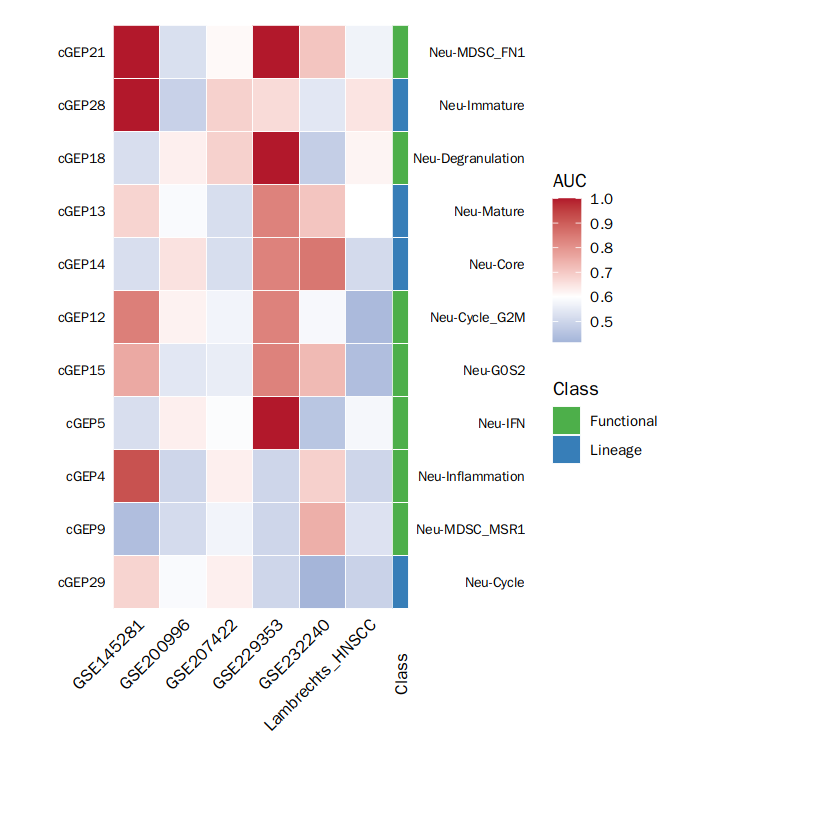

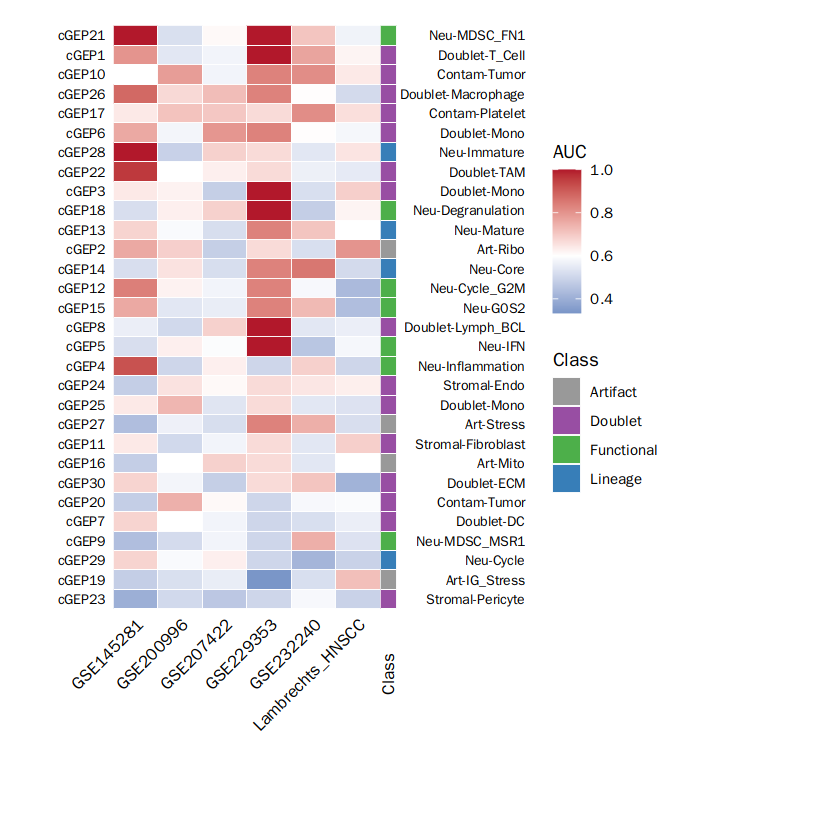

In [9]:
# 只保留 Function 和 Artifact
plot_Neutrophils_heatmap(
  heat_df = heat_df_filt,
  anno_df = Neu_cGEP,
  keep_categories = c("Functional","Lineage"),
  output_file = "./4.3.2.Neutrophils_usage_immu_pheatmap_GEP30/4.3.2.Neutrophils_cGEP30_usage_heatmap_filtered_sorted_mean.pdf",
  width = 12,
  height = 16
)

# 都留
plot_Neutrophils_heatmap(
  heat_df = heat_df_filt,
  anno_df = Neu_cGEP,
  keep_categories = c("Functional","Artifact","Lineage","Doublet"),
  output_file = "./4.3.2.Neutrophils_usage_immu_pheatmap_GEP30/4.3.2.Neutrophils_cGEP30_usage_heatmap_all_sorted_mean.pdf",
  width = 12,
  height = 16
)


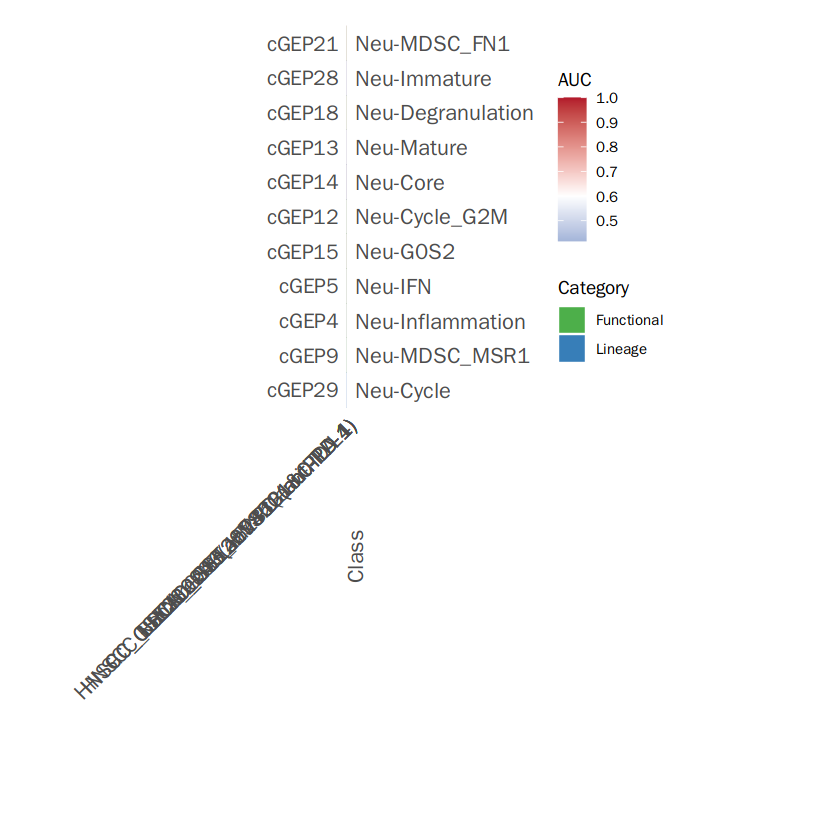

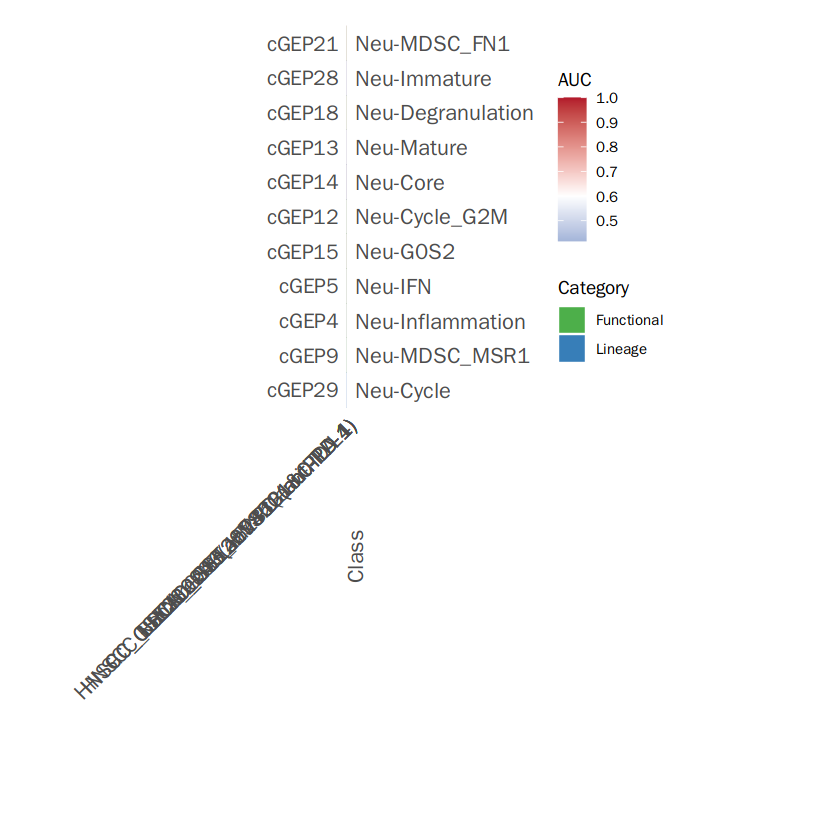

In [14]:
library(dplyr)
library(ggplot2)
library(patchwork)

plot_heatmap <- function(
  heat_df,
  anno_df,
  keep_categories,
  output_file,
  cell_width,
  cell_height,
  fill_midpoint = 0.6
){

  # 1️⃣ 排序
  sorted_cgeps <- heat_df %>%
    group_by(pathway) %>%
    summarise(mean_auc = mean(patient_auc, na.rm = TRUE)) %>%
    arrange(mean_auc) %>%
    pull(pathway)

  heat_df$pathway <- factor(heat_df$pathway, levels = sorted_cgeps)

  # 2️⃣ annotation过滤
  anno_df <- anno_df %>%
    filter(cGEP_Cluster %in% sorted_cgeps) %>%
    filter(Category %in% keep_categories) %>%
    arrange(match(cGEP_Cluster, sorted_cgeps))

  sorted_cgeps_filtered <- intersect(sorted_cgeps, unique(anno_df$cGEP_Cluster))

  anno_df$cGEP_Cluster <- factor(
    anno_df$cGEP_Cluster,
    levels = sorted_cgeps_filtered
  )

  anno_labels <- anno_df$cGEP_Anno_Name
  names(anno_labels) <- anno_df$cGEP_Cluster

  heat_df_filtered <- heat_df %>%
    filter(pathway %in% sorted_cgeps_filtered)

  heat_df_filtered$pathway <- factor(
    heat_df_filtered$pathway,
    levels = sorted_cgeps_filtered
  )

  # 3️⃣ 自动计算图尺寸
  n_row <- length(sorted_cgeps_filtered)
  n_col <- length(unique(heat_df_filtered$dataset))

  height <- n_row * cell_height + 4
  width  <- n_col * cell_width + 6

  # 4️⃣ 主热图
  p_main <- ggplot(
    heat_df_filtered,
    aes(dataset, pathway, fill = patient_auc)
  ) +
    geom_tile(color="white", linewidth=0.3) +
    scale_fill_gradient2(
      low="#2166AC",
      mid="white",
      high="#B2182B",
      midpoint=fill_midpoint,
      name="AUC"
    ) +
    scale_x_discrete(expand=c(0,0)) +
    scale_y_discrete(expand=c(0,0)) +
    theme_minimal() +
    theme(
      axis.text.x = element_text(
        angle=45,
        hjust=1,
        size=13,
        face="bold"
      ),
      axis.text.y = element_text(
        size=12,
        face="bold"
      ),
      panel.grid = element_blank(),
      axis.title = element_blank(),
      legend.position = "left",
      plot.margin = margin(10,0,80,160)
    )

  # 5️⃣ annotation
  fill_values <- setNames(
    c("#4daf4a","#377eb8","#999999","#984ea3")[
      match(keep_categories,
      c("Functional","Lineage","Artifact","Doublet"))
    ],
    keep_categories
  )

  p_side <- ggplot(
    anno_df,
    aes("Class", cGEP_Cluster, fill = Category)
  ) +
    geom_tile(color="white", linewidth=0.3) +
    scale_fill_manual(values = fill_values) +
    scale_x_discrete(expand=c(0,0)) +
    scale_y_discrete(
      expand=c(0,0),
      position="right",
      labels=anno_labels
    ) +
    theme_minimal() +
    theme(
      axis.text.x = element_text(
        angle=90,
        size=13,
        face="bold"
      ),
      axis.text.y = element_text(
        size=13,
        face="bold",
        hjust=0
      ),
      panel.grid = element_blank(),
      axis.title = element_blank(),
      plot.margin = margin(10,100,40,0)
    )

  # 6️⃣ 拼接
  final_plot <- (p_main | p_side) +
    plot_layout(widths=c(5,0.35), guides="collect") &
    theme(panel.spacing = unit(0,"pt"))

  # 7️⃣ 保存
  ggsave(
    output_file,
    final_plot,
    width = width,
    height = height,
    dpi = 300,
    limitsize = FALSE
  )

  return(final_plot)
}
# 只保留 Function 和 Artifact
plot_heatmap(
  heat_df = heat_df_filt2,
  anno_df = Neu_cGEP,
  keep_categories = c("Functional","Lineage"),
  output_file = "./4.3.2.Neutrophils_usage_immu_pheatmap_GEP30/4.3.2.Neutrophils_cGEP30_usage_paper-v0417.png",
  cell_width = 0.5,
  cell_height = 0.25
)
plot_heatmap(
  heat_df = heat_df_filt2,
  anno_df = Neu_cGEP,
  keep_categories = c("Functional","Lineage"),
  output_file = "./4.3.2.Neutrophils_usage_immu_pheatmap_GEP30/4.3.2.Neutrophils_cGEP30_usage_paper-v0417.pdf",
  cell_width = 0.5,
  cell_height = 0.25
)